# Feature-Size Analysis via 3D Radial Power Spectrum

Estimate the size of small spatial features in a reconstructed volume using a rigorous
3D Fourier (spectral) method.

**Pipeline**
1. Load volume, subtract the mean (kill the DC term).
2. Apply a soft circular window in the (Y, X) plane — a raised-cosine ring that stays
   at 1 inside the inscribed FOV and tapers smoothly to 0 only over the outermost few
   percent of the radius — to suppress edge/spectral leakage from the circular
   reconstruction boundary without clipping the reconstructed object.
3. Take the 3D FFT, square the magnitude to get the power spectrum.
4. Radially average the power over spherical shells of constant $|f|$ (isotropy assumed).
5. Convert each shell to a real-space feature size via $d = \Delta / f$.

**Reading the result**
- A bump in the power-vs-feature-size curve ⇒ a length scale (pore/filament size) that is
  especially present in the volume.
- The shell-volume-compensated spectrum $f^2\cdot$PSD makes such a peak stand out against the
  smoothly decaying background.

> Convention used throughout: feature size $d = \Delta / f$, where $f$ is spatial frequency in
> cycles/voxel and $\Delta$ is the voxel size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from scipy import fft as sfft
from scipy.ndimage import gaussian_filter

# ---- Parameters ----------------------------------------------------------
recon_location = "/home/ljh79/TomoMono/reconstructions/APSbeamtime_Oct25/tomopy/tomopyAlgorithmCheck_20260526-104352/cfg_fullres_aligned_20260514-115952_SIRT_CUDA_positivity_20260526-104352.tif"

voxel_size = 30.2         # nm per voxel
length_unit = "nm"

SOFT_CIRCLE_RATIO = 0.99  # outer FOV radius as a fraction of inscribed-circle radius
SOFT_CIRCLE_TAPER = 0.10  # raised-cosine taper width as a fraction of r_out
Z_PAD_LENGTH      = 50    # voxels of edge-replicated padding on each Z face (0 = off)
N_BINS = 600              # radial |f| shells (more bins → finer feature-size resolution)

## 1. Load the volume

volume shape (z, y, x): (400, 1200, 1200) | dtype: float32 | size: 2.30 GB


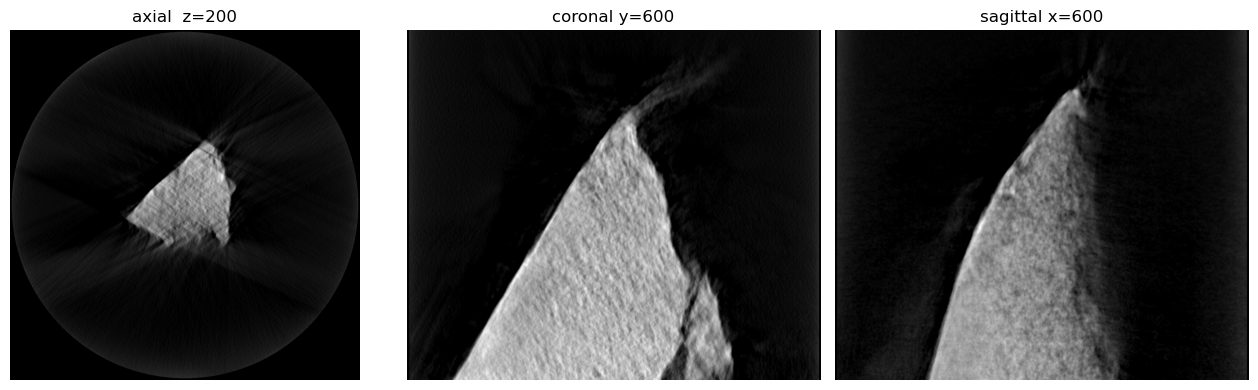

In [2]:
vol = tifffile.imread(recon_location).astype(np.float32, copy=False)
print("volume shape (z, y, x):", vol.shape, "| dtype:", vol.dtype,
      "| size: %.2f GB" % (vol.nbytes / 1e9))
nz, ny, nx = vol.shape

# Orthogonal central slices for a sanity check
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(vol[nz // 2], cmap="gray");      ax[0].set_title(f"axial  z={nz//2}")
ax[1].imshow(vol[:, ny // 2], cmap="gray", aspect="auto"); ax[1].set_title(f"coronal y={ny//2}")
ax[2].imshow(vol[:, :, nx // 2], cmap="gray", aspect="auto"); ax[2].set_title(f"sagittal x={nx//2}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


## 2. Mean subtraction + soft circular window + Z-face taper

We use the same **soft circular window** as `metrics/fsc.py`: a 2D raised-cosine ring mask
in the $(y, x)$ plane, broadcast uniformly over all $z$ slices.  The window equals 1
everywhere inside $r_\text{in} = r_\text{out}(1 - \text{taper})$, then rolls smoothly to
0 at $r_\text{out} = \text{ratio} \times \min(N_y,N_x)/2$ — the outer FOV edge.  With
the defaults (`ratio=0.99`, `taper=0.10`) the flat passband extends to **89 % of the FOV
radius** and the entire taper lives in the outer 10 % annulus, so the reconstructed object
is left completely unattenuated.

The circular mask handles all four in-plane edges, but the top and bottom $z$-faces still
carry a hard support boundary.  Mirroring the `_pad_taper_3d(axes=(0,))` call in
`metrics/fsc.py`, we pad each face by `Z_PAD_LENGTH` voxels using edge-replication, then
progressively blur those pad slabs outward (so the frozen edge profile decays toward a
flat level before it tapers to zero, avoiding spurious spatial frequencies in the FFT),
and finally apply a raised-cosine ramp to roll the padded edge to zero.

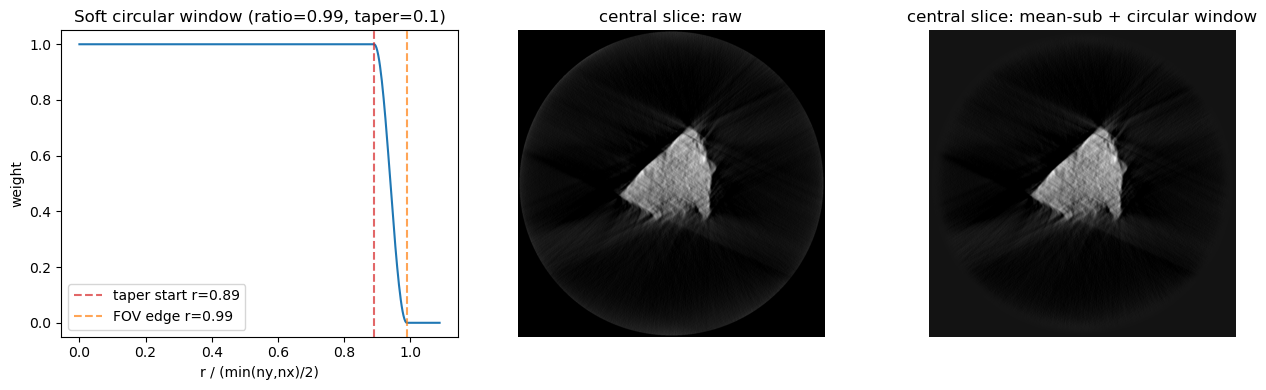

In [3]:
raw_slice = vol[nz // 2].copy()
vol -= vol.mean()  # remove DC

# ── Soft circular window (XY plane, broadcast over Z) ─────────────────────
# Same approach as _soft_circ_mask() in metrics/fsc.py:
#   r_out = SOFT_CIRCLE_RATIO * inscribed-circle radius
#   r_in  = r_out * (1 - SOFT_CIRCLE_TAPER)
# Weight = 1 inside r_in, raised-cosine taper from r_in → r_out, 0 outside.
cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
yy = np.arange(ny, dtype=np.float32) - cy
xx = np.arange(nx, dtype=np.float32) - cx
rr = np.sqrt(yy[:, None]**2 + xx[None, :]**2)

r_out = SOFT_CIRCLE_RATIO * min(ny, nx) / 2.0
r_in  = r_out * (1.0 - SOFT_CIRCLE_TAPER)
mask2d = np.ones((ny, nx), dtype=np.float32)
edge = (rr > r_in) & (rr <= r_out)
mask2d[edge] = 0.5 * (1.0 + np.cos(np.pi * (rr[edge] - r_in) / (r_out - r_in)))
mask2d[rr > r_out] = 0.0
vol *= mask2d[None, :, :]  # broadcast over all Z slices

# ── Z-axis edge-replicated padding + progressive blur + taper ─────────────
# Mirrors _pad_taper_3d(axes=(0,)) from metrics/fsc.py.
# 1. Pad each Z face with Z_PAD_LENGTH voxels of edge-replicated content so
#    the taper doesn't eat into the reconstructed object.
# 2. Progressively Gaussian-blur each pad slice outward so the frozen edge
#    profile relaxes toward a flat level (no sharp lateral content to transform).
# 3. Apply a raised-cosine (sin²) ramp over the pad strip to roll it to zero.
if Z_PAD_LENGTH > 0:
    vol = np.pad(vol, ((Z_PAD_LENGTH, Z_PAD_LENGTH), (0, 0), (0, 0)), mode='edge')
    nz = vol.shape[0]       # update nz so downstream cells use the padded size

    BLUR_SIGMA = 0.7        # per-layer Gaussian σ; compounds outward ~σ√k after k layers
    prev = vol[Z_PAD_LENGTH].copy()
    for k in range(Z_PAD_LENGTH - 1, -1, -1):
        prev = gaussian_filter(prev, BLUR_SIGMA)
        vol[k] = prev
    prev = vol[nz - Z_PAD_LENGTH - 1].copy()
    for k in range(nz - Z_PAD_LENGTH, nz):
        prev = gaussian_filter(prev, BLUR_SIGMA)
        vol[k] = prev

    te = Z_PAD_LENGTH
    ramp_z = np.sin(0.5 * np.pi * np.arange(te, dtype=np.float32) / te) ** 2
    vol[:te]      *= ramp_z[:, None, None]
    vol[nz - te:] *= ramp_z[::-1, None, None]

# Radial profile for visualization
r_prof = np.linspace(0, 1.1 * r_out, 400)
w_prof = np.ones(len(r_prof), dtype=np.float32)
e_prof = (r_prof > r_in) & (r_prof <= r_out)
w_prof[e_prof] = 0.5 * (1.0 + np.cos(np.pi * (r_prof[e_prof] - r_in) / (r_out - r_in)))
w_prof[r_prof > r_out] = 0.0
r_norm = r_prof / (min(ny, nx) / 2.0)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(r_norm, w_prof)
ax[0].axvline(r_in / (min(ny, nx) / 2.0), color="C3", ls="--", alpha=0.7,
              label=f"taper start r={r_in / (min(ny, nx) / 2.0):.2f}")
ax[0].axvline(SOFT_CIRCLE_RATIO, color="C1", ls="--", alpha=0.7,
              label=f"FOV edge r={SOFT_CIRCLE_RATIO:.2f}")
ax[0].set_title(f"Soft circular window (ratio={SOFT_CIRCLE_RATIO}, taper={SOFT_CIRCLE_TAPER})")
ax[0].set_xlabel("r / (min(ny,nx)/2)"); ax[0].set_ylabel("weight"); ax[0].legend()
ax[1].imshow(raw_slice, cmap="gray"); ax[1].set_title("central slice: raw"); ax[1].axis("off")
ax[2].imshow(vol[nz // 2], cmap="gray")
ax[2].set_title("central slice: mean-sub + circular window"); ax[2].axis("off")
plt.tight_layout(); plt.show()
del raw_slice

## 3. 3D FFT → radial power spectrum → feature sizes

Take the 3D Fourier transform of the windowed volume, square it to get the power
spectrum, and **radially average the power over spherical shells of constant $|f|$**
(isotropy assumed). Each shell at spatial frequency $f$ (cycles/voxel) corresponds to a
real-space feature size $d = \Delta / f$ (with $\Delta$ = `voxel_size`).

Plotting power vs. feature size shows which length scales carry the most spectral
energy — a bump at a given size means that spacing (e.g. a pore or filament width) is
especially present in the volume. The shell-volume-compensated spectrum $f^2\cdot$PSD
makes such a peak stand out against the smoothly decaying background.

half-spectrum power shape: (500, 1200, 601) | 1.44 GB


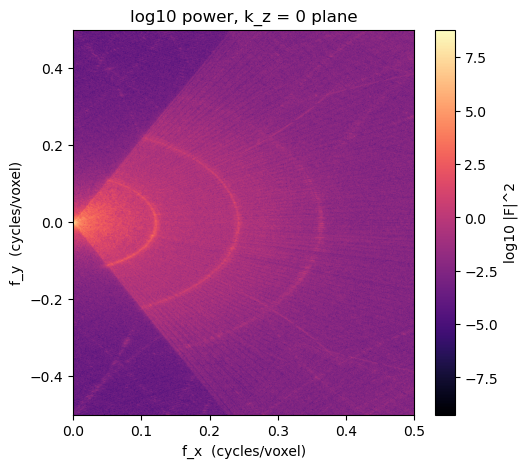

In [4]:
from scipy.signal import find_peaks

# ── 3D FFT power spectrum (rfftn = memory-efficient real-input half-spectrum) ──
power = np.abs(sfft.rfftn(vol, workers=-1)).astype(np.float32) ** 2
del vol
print("half-spectrum power shape:", power.shape, "| %.2f GB" % (power.nbytes / 1e9))

# log-power slice through the kz = 0 plane (fftshift only the fy axis for display)
disp = np.log10(power[0] + 1e-12)
disp = np.fft.fftshift(disp, axes=0)
plt.figure(figsize=(5.5, 5))
plt.imshow(disp, cmap="magma", aspect="auto", extent=[0, 0.5, -0.5, 0.5])
plt.xlabel("f_x  (cycles/voxel)"); plt.ylabel("f_y  (cycles/voxel)")
plt.title("log10 power, k_z = 0 plane"); plt.colorbar(label="log10 |F|^2"); plt.show()

No dominant feature size — spectrum is featureless/monotonic.
Resolvable range: 60.4 nm (2-voxel Nyquist) to 14496 nm


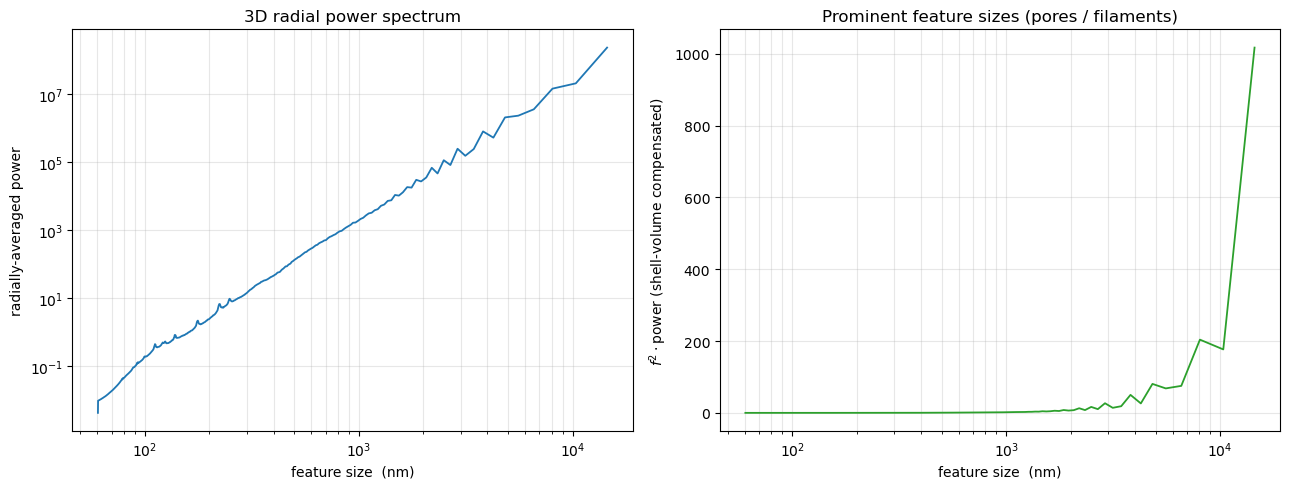

In [5]:
# ── Radial average over spherical shells of constant |f| ──────────────────────
fz = np.fft.fftfreq(nz).astype(np.float32)
fy = np.fft.fftfreq(ny).astype(np.float32)
fx = np.fft.rfftfreq(nx).astype(np.float32)        # last axis: 0 .. 0.5 (rfftn)
fmag = np.sqrt(fz[:, None, None]**2 + fy[None, :, None]**2 + fx[None, None, :]**2)

f_ny = 0.5                                          # Nyquist = 0.5 cycles/voxel
bin_idx = np.clip((fmag.ravel() / f_ny * N_BINS).astype(np.int64), 0, N_BINS - 1)
psum = np.bincount(bin_idx, weights=power.ravel(), minlength=N_BINS)
pcnt = np.bincount(bin_idx, minlength=N_BINS)
psd  = psum / np.maximum(pcnt, 1)
del power, fmag, bin_idx

# ── Convert each shell to a real-space feature size d = voxel_size / f ────────
f_centers = (np.arange(N_BINS) + 0.5) / N_BINS * f_ny      # cycles/voxel
keep = (np.arange(N_BINS) >= 2) & (pcnt > 0)               # drop DC / empty shells
fc, ps = f_centers[keep], psd[keep]
feat = voxel_size / fc                                      # feature size (length_unit)

# Shell-volume compensation makes a dominant size stand out as a peak
comp = ps * fc**2
peaks, _ = find_peaks(comp, prominence=comp.max() * 0.05)
if len(peaks):
    d_star = feat[peaks[np.argmax(comp[peaks])]]
    print(f"Most prominent feature size: {d_star:.1f} {length_unit} "
          f"({d_star / voxel_size:.1f} voxels)")
else:
    d_star = None
    print("No dominant feature size — spectrum is featureless/monotonic.")
print(f"Resolvable range: {2*voxel_size:.1f} {length_unit} (2-voxel Nyquist) "
      f"to {feat.max():.0f} {length_unit}")

# ── Plot power vs. feature size ───────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(feat, ps, lw=1.3)
ax[0].set_xlabel(f"feature size  ({length_unit})")
ax[0].set_ylabel("radially-averaged power")
ax[0].set_title("3D radial power spectrum")
ax[0].grid(True, which="both", alpha=0.3)

ax[1].semilogx(feat, comp, lw=1.3, color="C2")
if d_star:
    ax[1].axvline(d_star, color="C3", ls="--", label=f"peak ≈ {d_star:.1f} {length_unit}")
    ax[1].legend()
ax[1].set_xlabel(f"feature size  ({length_unit})")
ax[1].set_ylabel(r"$f^2\cdot$power (shell-volume compensated)")
ax[1].set_title("Prominent feature sizes (pores / filaments)")
ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()
